# 🧠🤖 Regressão Linear usando Gradient Descent

Esta é uma aula prática e o objetivo é que você exercite o uso do algoritmo de descida do gradiente (*gradient descent*) na resolução de um problema real. Vamos usar como tarefa de exemplo o problema de regressão linear univariada. 

Ao longo da aula, você será conduzido a realizar as seguintes atividades: 

- Conhecer uma forma de modelar a tarefa de regressão linear;
- Implementar modelos de regressão;
- Implementar a função de perda que define o erro do modelo;
- Calcular as derivadas parciais da função de perda em relação aos parâmetros;
- Treinar os parâmetros usando descida do gradiente;
- Visualizar a evolução da função de perda ao longo do treinamento;
- Visualizar as curvas aprendidas pelos modelos;


## Regressão 

Como ilustrado nas figuras abaixo, dado um conjunto de treinamento $D = {(x_i, y_i)}$, queremos encontrar uma função $f(x)$, com parâmetros treináveis $w$, que seja uma **boa aproximação** da função que gerou os pontos. Isto é, queremos encontrar uma função capaz de **predizer o valor de y** com pequeno erro para o conjunto de treinamento e que permita **estimar** o valor de $y$ em outras posições. 


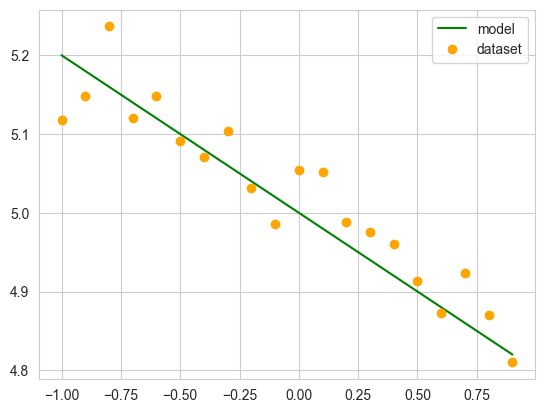


## Regressão Linear


No caso de **regressão linear**, nós assumimos que a função $f$ é uma reta e os parâmetros treináveis são o ângulo da reta e o ponto de contato com o eixo y. Isto é:

$$
f(x) = w_1 x + w_0
$$


## Função de Perda ou Função Objetivo

A função de perda (*loss function*) é aquela que será minimizada durante o treinamento do modelo. A função de perda mais utilizada em problemas de regressão é o erro médio quadrático (*mean squared error* - MSE). Como ilustrado na figura abaixo, primeiro usamos o modelo para predizer o valor da coordenada  $y$ para cada valor de $x_i \in D$. Em seguida, calculamos a diferença entre as predições e os valores reais. O erro total do modelo será a média das diferenças ao quadrado.

Matematicamente, a função de erro $L$ para um modelo $f$ será dada por:

$$
L = \frac{1}{n} \sum_{i=1}^{n} (y_i - f(x_i))^2 = \frac{1}{n} \left[  (y_0 - f(x_0))^2 + \cdots + (y_n - f(x_n))^2  \right]
$$


🎯 **Nota**: Usamos o quadrado das diferenças porque as diferenças podem ser positivas ou negativas e a função módulo (valor absoluto) não é diferenciável. 


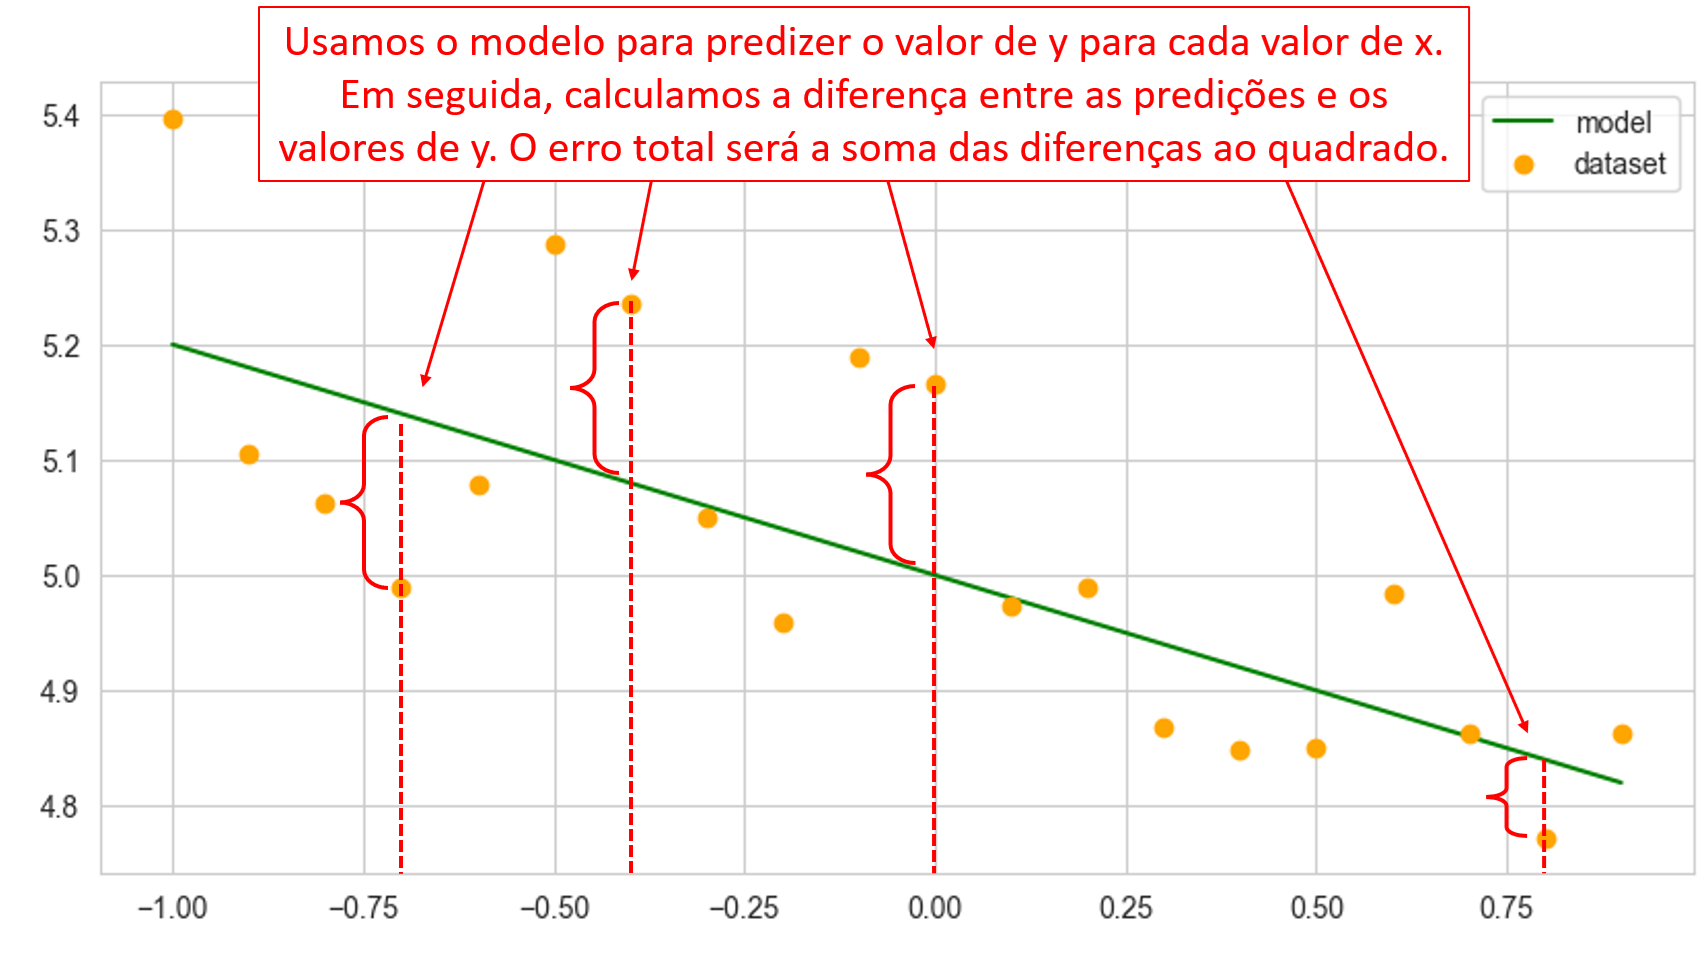

## Atividades de Implementação

Nesta tarefa, vamos criar e treinar um modelo de regressão linear univariada. 


### Preparação

In [1]:
import numpy as np

A função abaixo é utilizada para plotar os pontos e, opcionalmente, a função estimada pelo modelo. Ela recebe como entrada: 
- `x`: valores de $x$ do dataset
- `y` : valores de $y$ do dataset
- `model_fn`: modelo usado para predizer o valor de $y$ a partir de $x$ (opcional). 
- `low`: limite inferior de $x$ para produção do gráfico.
- `high`: limite superior de $x$ para produção do gráfico.
- `step`: passo em $x$ para produção do gráfico. 

🎯 **Nota:** Usamos valores inferiores, superiores e passo independentes nesta função para termos liberdade de produzir o gráfico com resolução mais fina que aquela utilizada para produzir o dataset.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.close('all')

def plot(x, y, model_fn=None, low=-1, high=1, step=0.01):
    # gera intervalo de pontos no eixo x
    chart_x = np.arange(low, high, step)

    # se o modelo foi passado, ele eh usada para calcular os valores y estimados e a curva é plotada
    if model_fn:
        model_y = [model_fn(sample_i) for sample_i in chart_x]
        plt.plot(chart_x, model_y, '-', color='green', label='model')

    # plota o dataset
    plt.plot(x, y, 'o', color='red', label='dataset')
    plt.legend()


### Dataset

As células abaixo lêem e exibem um dataset de exemplo. Os arquivos estão disponíveis no Testr.

In [17]:
with open("ds_0.txt", "r") as f:
    data = np.array([line.strip().split() for line in f.readlines()]).astype(np.float32)

x = data[:, 0]
y = data[:, 1]

print(x.shape, y.shape)


(20,) (20,)


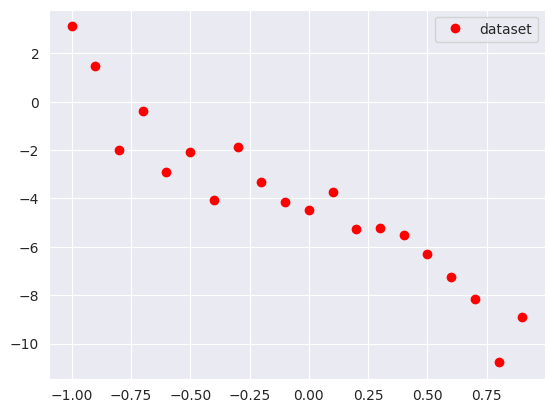

In [18]:
# plota o dataset
plot(x, y)

### Atividade: Criar uma classe para representar o modelo.

Implemente a classe `LinearRegression` para representar o nosso modelo. Ele deve implementar a seguinte função: 

$$
f(x) = x w_1 + w_0 
$$

Para isto, crie os seguintes métodos:
- `construtor`: recebe e armazena os parâmetros da reta.
- `foward`: calcula o valor da função para um valor de $x$ dado.


In [83]:
# resposta

class LinearRegression:
    def __init__(self, w0, w1):
        # recebe e armazena internamente os valores de w_0 e w_1 de acordo
        self.w0 = w0
        self.w1 = w1

    def forward(self, x):
        # calcula o valor de y da reta para um dado valor de x
        return x * self.w1 + self.w0


w0 = np.random.random()
w1 = np.random.random()
model = LinearRegression(w0, w1)
model.forward(3)


1.690071184998649

Mostra a reta aleatória na tela:

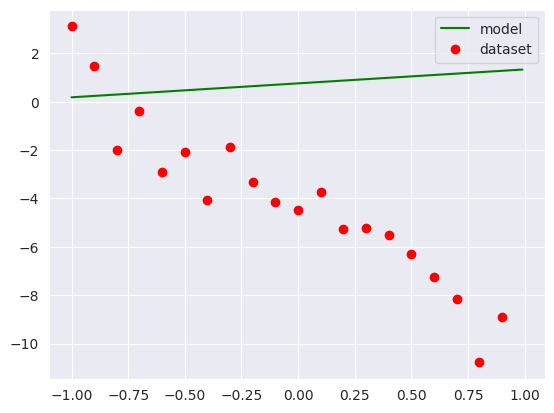

In [44]:
# 🎯 Note que podemos usar o método forward como "ponteiro de função"
plot(x, y, model_fn=model.forward)

### Atividade: Implementar a função de perda

Dadas as variáveis $x$ e $y$ (listas de números ou arrays do numpy) contendo as coordenadas $x_i$ e $y_i$ dos pontos, respectivamente, implemente a função MSE para calcular o erro do modelo. Use cada $x_i$ como entrada para o método `forward` para prever o valor de y usando a reta, eleve as diferentes ao quadrado e tire a média. 

Para testar a função calcule o erro do modelo antes do treinamento. 

In [45]:
# resposta

def loss_fn(x, y, model_fn):
    return np.mean((y - model_fn(x)) ** 2)


Mostra o erro calculado usando a função implementada acima:

In [47]:
loss_fn(x, y, model.forward)

np.float32(36.24416)

### Atividade: Calcular as derivadas parciais do erro em relação aos parâmetros

Para implementar o algoritmo de descida do gradiente, precisamos calcular a derivada do erro em relação aos parâmetros. 

Como vimos anteriormente, o erro será dado por:



$$
L = \frac{1}{N} \sum_{i=1}^n (y_i - f(x_i))^2
$$

Substituindo $f(x)$ por sua expressão:

$$
L = \frac{1}{N} \sum_{i=1}^n (y_i - (w_1 x_i + w_0))^2 
$$

Portanto:

$$
L = \frac{1}{N} \sum_{i=1}^n (y_i - w_1 x_i - w_0)^2
$$


Calcule os valores das derivadas parciais do erro em relação aos parâmetros $w_0$ e $w_1$.

$$
\frac{\partial L}{\partial w_1} = ?
$$

$$
\frac{\partial L}{\partial w_0} = ?
$$


Tente fazer sozinho, mas em caso de dificuldade, a derivação completa está no fim do notebook.

### Atividade: Usar o algoritmo de descida do gradiente para ajustar a reta

Implemente a função `gd_train`. A função recebe como entrada as coordenadas `x` e `y` dos pontos, o modelo com parâmetros inicializados aleatoriamente, a taxa de aprendizado `lr` e o número de épocas `n_epochs`. Em python, a passagem de parãmetros é sempre realizada por referências. Portanto, ajustes nos atributos do modelo feitas dentro da função irão persistir ao final dela. A função deve retornar uma lista `history` os valores dos parâmetros do modelo e o valor da loss ao final de cada época. Esta lista será utilizada para visualizar como foi o andamento do treinamento. Se o algoritmo estiver correto, o valor da função de perda deve decrescer ao longo das épocas. 

In [77]:
# resposta

def calculaDerivadas(xi,yi,w0,w1):
    return (-2*yi+2*w1*xi+2*w0, -2*xi*yi+2*w1*xi**2+2*w0*xi)

def gd_train(x, y, model, lr, n_epochs):
    history = []

    # itera sobre o dataset por um numero de epocas
    for _ in range(n_epochs):
        # renicie os gradientes com zero para iniciar uma nova epoca
        grad_w1 = 0
        grad_w0 = 0

        # calcule os gradientes
        derivada_w0, derivada_w1 = calculaDerivadas(x,y,model.w0,model.w1)
        grad_w1 = np.mean(derivada_w1)
        grad_w0 = np.mean(derivada_w0)

        # Realize o passo de descida do gradiente, isto é, atualiza os parâmetros usando os gradientes.
        model.w0 -= lr * grad_w0
        model.w1 -= lr * grad_w1

        # Calcula a loss da epoca atual para averiguarmos se ela está diminuindo
        loss = loss_fn(x, y, model.forward)

        # adiciona os parâmetros e a loss na variavel de historico
        # IMPORTANTE: pode ser necessário mudar o nome dos atributos do modelo.
        history.append([model.w0, model.w1, loss])

    return history

# reinicializa os parametros
w0 = np.random.random()
w1 = np.random.random()
model = LinearRegression(w0, w1)

# treina
history = gd_train(x, y, model, lr=1e-1, n_epochs=20)

# mostra o erro ao longo das epocas
for idx, h in enumerate(history):
    loss = h[-1]
    print(f"Epoch {idx}: {h[-1]}")

Epoch 0: 35.279361724853516
Epoch 1: 34.19841766357422
Epoch 2: 33.237449645996094
Epoch 3: 32.38798522949219
Epoch 4: 31.640819549560547
Epoch 5: 30.98651123046875
Epoch 6: 30.41579818725586
Epoch 7: 29.9198055267334
Epoch 8: 29.490238189697266
Epoch 9: 29.119403839111328
Epoch 10: 28.800312042236328
Epoch 11: 28.5266170501709
Epoch 12: 28.292633056640625
Epoch 13: 28.09328269958496
Epoch 14: 27.92405128479004
Epoch 15: 27.780956268310547
Epoch 16: 27.660486221313477
Epoch 17: 27.559551239013672
Epoch 18: 27.475448608398438
Epoch 19: 27.40581703186035


### Análise dos resultados

A célula abaixo mostra o valor da função de perda ao longo do treinamento. Se tudo estiver correto, a função deve decrescer ao longo das épocas.

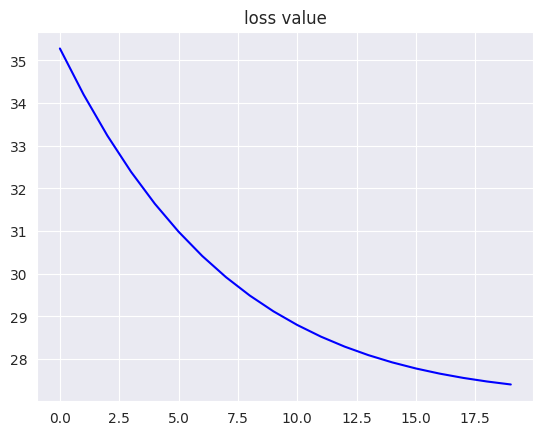

In [79]:
plt.plot([h[-1] for h in history], '-', color='blue')
plt.title('loss value')
plt.show()

A célula abaixo mostra como a reta mudou ao longo das épocas. Se tudo deu certo, a reta deve ficar no meio dos pontos ao final.

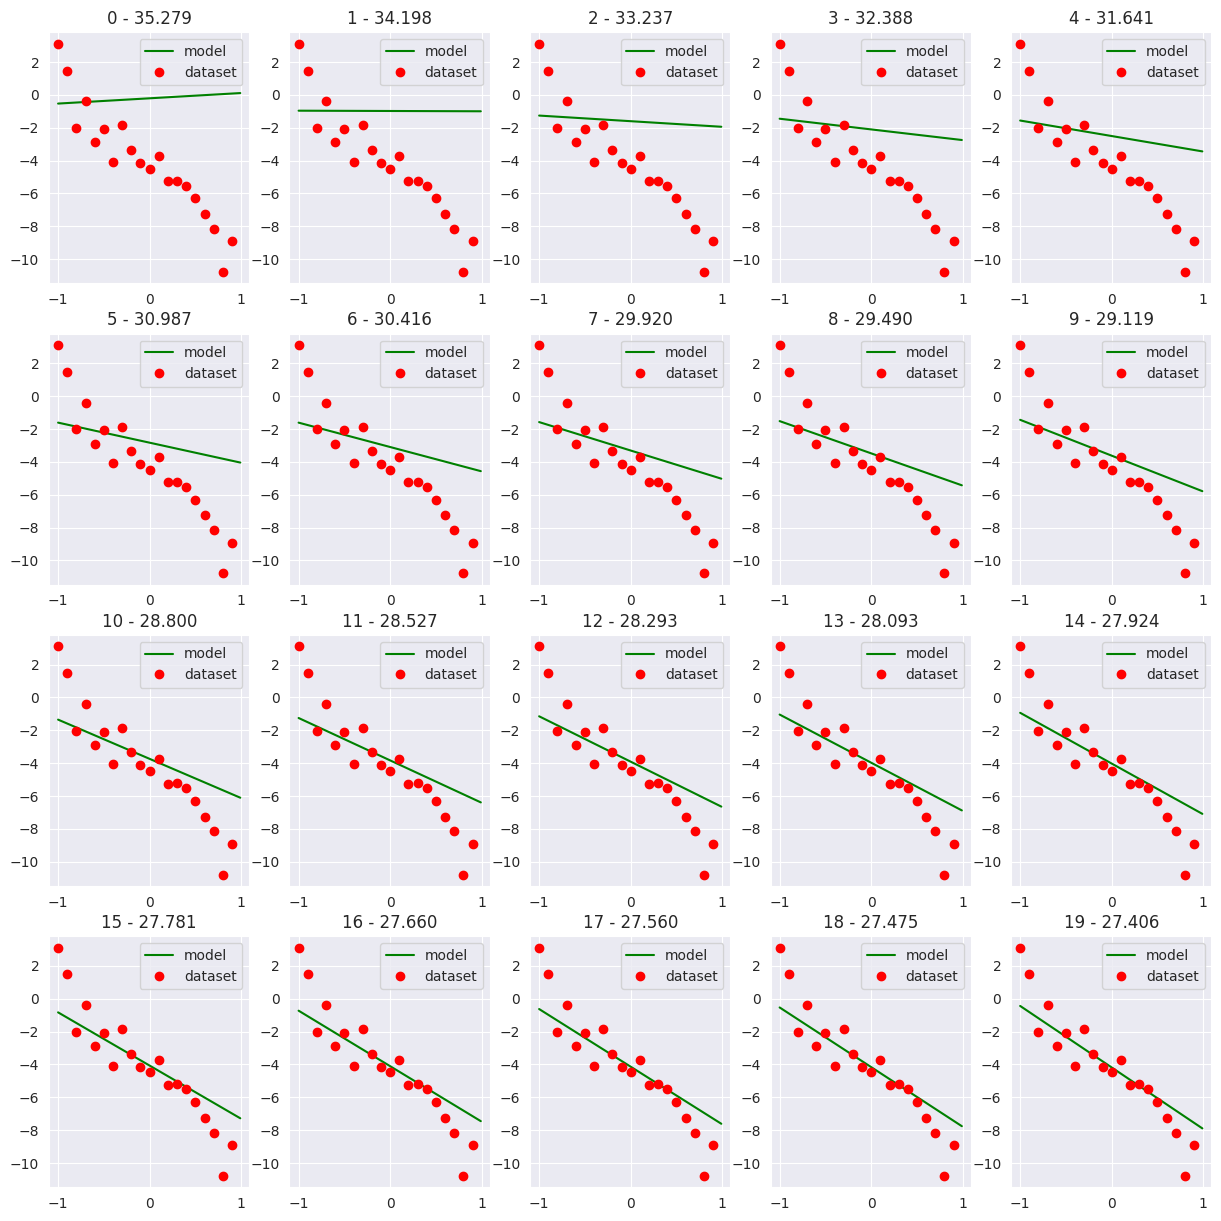

In [84]:

plt.figure(figsize=(15, 15))
for epoch, h in enumerate(history):

    # ##################################
    # IMPORTANTE: Pode ser necessário mudar as linhas abaixo dependendo do nome
    # que você deu para os parâmetros.
    # ##################################
    model.w0 = h[0]
    model.w1 = h[1]

    plt.subplot(4, 5, epoch+1)
    plt.title(f"{epoch} - {h[2]:.3f}")
    plot(x, y, model_fn=model.forward, low=-1, high=1)
plt.show()

--- 

## Cálculo das derivadas (Resposta)

Cálculo de $\frac{\partial L}{\partial w_1}$:


$$
\frac{\partial L}{\partial w_1} = \frac{\partial}{\partial w_1} \frac{1}{N} \sum_{i=1}^n (y_i - w_1 x_i - w_0)^2
$$


Usando as regras da derivada de constantes multiplicativas e da derivada da soma, temos que a expressão acima equivale a: 




$$
\frac{\partial L}{\partial w_1} = \frac{1}{N} \sum_{i=1}^n \frac{\partial}{\partial w_1} (y_i - w_1 x_i - w_0)^2
$$


Usando a regra da cadeia:

$$
\frac{\partial L}{\partial w_1} = \frac{1}{N} \sum_{i=1}^n  2 (y_i - w_1 x_i - w_0) \frac{\partial}{\partial w_1} \left[ y_i - w_1 x_i - w_0 \right]
$$

Como $x_i$ e $y_i$ são contantes vindas do dataset e $w_0$ pode ser tratada como uma constante quando derivando em relação a $w_1$, temos: 

$$
\frac{\partial L}{\partial w_1} = \frac{1}{N} \sum_{i=1}^n  2 (y_i - w_1 x_i - w_0)  (-x_i)
$$


Usando o mesmo raciocínio, podemos chegar em: 

$$
\frac{\partial L}{\partial w_0} = \sum_{i=1}^N \frac{2}{N} (y_i - w_1 x_i - w_0) (-1)
$$
